In [24]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

rng = np.random.default_rng(42)

## HyperDeepONet

-, Step 1: load data \
-, Step 2: Training \
-, Step 3: Test performance & Tracking

#### Step 1: Load data

In [25]:
def plot_solution(x, u_0, u_t, t_plot,dt):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

    ax1.plot(x, u_0, label="t = 0.00")
    ax1.set_xlabel("x")
    ax1.set_ylabel("u")
    ax1.set_title("Initial Condition Shock")
    ax1.legend()
    ax1.grid()

    ax2.plot(x, u_t[int(t_plot/dt)], label="t = %.2f" % t_plot)
    ax2.scatter(x, u_t[int(t_plot/dt)], color='red', s=5, label="samples", alpha=0.8)
    ax2.set_xlabel("x")
    ax2.set_title("Godunov flux solver")
    ax2.legend()
    ax2.grid()

    plt.tight_layout()
    plt.show()

N_data = 500
data = np.load(f"data/linear_advection_dataset_N_{N_data}.npz", allow_pickle=True)

input_data = data["u0"]
output_data = data["u"]
discon_x_data = data["discontinuities"]
x = data["x"]
t_domain = data["t"]

train_idx = data["train_idx"],
val_idx = data["val_idx"],
test_idx = data["test_idx"]

print("input shape - different u_0:", input_data.shape)
print("output shape - different u_t:", output_data.shape)
print("x shape:", x.shape)
print("t_domain shape:", t_domain.shape)
# plot_solution(x, input_data[0, :], output_data[0, :], t_domain[200], dt=t_domain[1]-t_domain[0])

input shape - different u_0: (500, 500)
output shape - different u_t: (500, 15, 500)
x shape: (500,)
t_domain shape: (15,)


#### Step 2: Training

In [ ]:
# ---------------------------
# 1) Prepare data
# ---------------------------
input = input_data.astype(np.float32)          # (N, Nx)
output = output_data.astype(np.float32)        # (N, Nt, Nx)
N, Nx, Nt = input_data.shape[0], x.shape[0], t_domain.shape[0]

# coordinate grid for trunk input: (x, t)
xx, tt = np.meshgrid(x.astype(np.float32), t_domain.astype(np.float32), indexing="xy")
coords_np = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

# ---------------------------
# 2) Define HyperDeepONet
# ---------------------------
class MLP(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, depth=3, activation=nn.Tanh):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), activation()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), activation()]
        layers += [nn.Linear(hidden_dim, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

class HyperNetwork(nn.Module):
    def __init__(self, branch_in, hidden_dim, param_dim, depth=3):
        super().__init__()
        self.net = MLP(branch_in, hidden_dim, param_dim, depth=depth)

    def forward(self, u):
        return self.net(u)   # (B, param_dim)

class TargetNetworkSpec:
    def __init__(self, layer_dims):
        self.layer_dims = layer_dims
        self.shapes = []
        self.param_dim = 0

        for in_dim, out_dim in zip(layer_dims[:-1], layer_dims[1:]):
            w_numel = out_dim * in_dim
            b_numel = out_dim
            self.shapes.append({
                "W_shape": (out_dim, in_dim),
                "b_shape": (out_dim,),
                "W_numel": w_numel,
                "b_numel": b_numel,
            })
            self.param_dim += w_numel + b_numel

    def unflatten(self, flat_params):
        B = flat_params.shape[0]
        params = []
        start = 0

        for spec in self.shapes:
            w_numel = spec["W_numel"]
            b_numel = spec["b_numel"]
            out_dim, in_dim = spec["W_shape"]

            W = flat_params[:, start:start + w_numel].reshape(B, out_dim, in_dim)
            start += w_numel

            b = flat_params[:, start:start + b_numel].reshape(B, out_dim)
            start += b_numel

            params.append((W, b))

        return params

class HyperDeepONet(nn.Module):
    def __init__(self, branch_in, target_layer_dims=(2, 64, 64, 1), hyper_hidden_dim=256, hyper_depth=3, activation=torch.tanh):
        super().__init__()

        self.target_spec = TargetNetworkSpec(list(target_layer_dims))
        self.hypernet = HyperNetwork(branch_in=branch_in, hidden_dim=hyper_hidden_dim, param_dim=self.target_spec.param_dim, depth=hyper_depth)
        self.activation = activation

    def forward(self, branch_input, trunk_input):
        B, P = branch_input.shape[0], trunk_input.shape[0]

        # Generate sample-specific target-network parameters
        flat_params = self.hypernet(branch_input)         # (B, param_dim)
        layer_params = self.target_spec.unflatten(flat_params)

        # Expand coordinates so each sample uses its own generated network
        h = trunk_input.unsqueeze(0).expand(B, P, -1)     # (B, P, 2)

        # Apply target network layer by layer
        num_layers = len(layer_params)
        for i, (W, b) in enumerate(layer_params):
            h = torch.einsum("bpi,boi->bpo", h, W) + b.unsqueeze(1)

            if i < num_layers - 1:
                h = self.activation(h)

        # final h: (B, P, 1)
        return h.squeeze(-1)   # (B, P)

# ---------------------------
# 3) Instantiate model
# ---------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HyperDeepONet(branch_in=Nx,target_layer_dims=(2, 64, 64, 1), hyper_hidden_dim=150,hyper_depth=3).to(device)

optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-6)
loss_fn = nn.MSELoss()

# ---------------------------
# 3) Train
# ---------------------------
epochs = 500
batch_size = 16
points_per_step = 2000  # sampled (x,t) points per batch
train_losses, val_losses = [], []

for epoch in range(1, epochs + 1):
    model.train()
    rng.shuffle(train_idx)
    epoch_loss = 0.0
    n_batches = 0

    for start in range(0, len(train_idx), batch_size):
        # Input and Output for the current batch
        batched_idx = train_idx[start:start + batch_size]
        batched_input = torch.tensor(input[batched_idx], dtype=torch.float32, device=device)   # (B, Nx)
        batched_output = torch.tensor(output[batched_idx], dtype=torch.float32, device=device) # (B, Nt, Nx)

        # Randomly sample points in the (t,x) domain for training
        point_idx = rng.integers(0, Nt * Nx, size=points_per_step)
        t_idx, x_idx = point_idx // Nx, point_idx % Nx

        # Trunk input and target output for the sampled points
        trunk_pts = torch.tensor(coords_np[point_idx], dtype=torch.float32, device=device)  # (P, 2)
        output_target = torch.tensor(batched_output[:, t_idx, x_idx], dtype=torch.float32, device=device)  # (P, B)

        optimizer.zero_grad()
        output_pred = model(batched_input, trunk_pts)
        loss = loss_fn(output_pred, output_target)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        n_batches += 1

    train_losses.append(epoch_loss / max(n_batches, 1))

    # quick validation (random sampled points)
    model.eval()
    with torch.no_grad():
        batched_val = val_idx if len(val_idx) <= 32 else rng.choice(val_idx, size=32, replace=False)
        batched_input_val = torch.tensor(input[batched_val], dtype=torch.float32, device=device)
        batched_output_val = output[batched_val]
        
        point_idx = rng.integers(0, Nt * Nx, size=points_per_step)
        t_idx, x_idx = point_idx // Nx, point_idx % Nx

        trunk_val = torch.tensor(coords_np[point_idx], dtype=torch.float32, device=device)
        y_val_target = torch.tensor(batched_output_val[:, t_idx, x_idx], dtype=torch.float32, device=device)

        y_val_pred = model(batched_input_val, trunk_val)
        val_loss = loss_fn(y_val_pred, y_val_target).item()
        val_losses.append(val_loss)

    if epoch % 20 == 0 or epoch == 1:
        print(f"Epoch {epoch:4d}/{epochs} | train_loss={train_losses[-1]:.6e} | val_loss={val_losses[-1]:.6e}")

# save checkpoint
checkpoint = {
    "model_state_dict": model.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "epochs": epochs,
    "train_losses": train_losses,
    "val_losses": val_losses
}

torch.save(checkpoint, "checkpoints/hyper_deeponet_checkpoint.pt")
print("Saved: hyper_deeponet_checkpoint.pt")

C:\Users\Ha\AppData\Local\Temp\ipykernel_13488\1493380154.py:136: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  output_target = torch.tensor(batched_output[:, t_idx, x_idx], dtype=torch.float32, device=device)  # (P, B)


Epoch    1/500 | train_loss=9.323785e-02 | val_loss=7.395416e-02
Epoch   20/500 | train_loss=5.757352e-02 | val_loss=7.257639e-02
Epoch   40/500 | train_loss=5.529257e-02 | val_loss=7.213931e-02
Epoch   60/500 | train_loss=5.467165e-02 | val_loss=7.330184e-02
Epoch   80/500 | train_loss=5.527416e-02 | val_loss=7.168957e-02
Epoch  100/500 | train_loss=5.521348e-02 | val_loss=7.120159e-02
Epoch  120/500 | train_loss=5.501107e-02 | val_loss=7.126020e-02
Epoch  140/500 | train_loss=5.642166e-02 | val_loss=7.024246e-02
Epoch  160/500 | train_loss=5.482111e-02 | val_loss=7.064279e-02
Epoch  180/500 | train_loss=5.645251e-02 | val_loss=7.288647e-02
Epoch  200/500 | train_loss=5.165366e-02 | val_loss=6.546458e-02
Epoch  220/500 | train_loss=2.539657e-02 | val_loss=2.500633e-02
Epoch  240/500 | train_loss=1.578281e-02 | val_loss=1.771236e-02
Epoch  260/500 | train_loss=1.372179e-02 | val_loss=1.586098e-02
Epoch  280/500 | train_loss=1.174847e-02 | val_loss=1.330158e-02
Epoch  300/500 | train_lo

#### Step 3: Test performance & Tracking

In [27]:
def predict_full_field(model, x_func_np, coords_np, Nt, Nx, chunk=20000):
    preds = []
    x_func = torch.tensor(x_func_np[None, :], dtype=torch.float32, device=device)  # (1, Nx)
    with torch.no_grad():
        for i in range(0, coords_np.shape[0], chunk):
            c = torch.tensor(coords_np[i:i+chunk], dtype=torch.float32, device=device)
            p = model(x_func, c).squeeze(0).cpu().numpy()
            preds.append(p)

    return np.concatenate(preds).reshape(Nt, Nx)

def error_analysis_all_t(pred, true, xx, true_discon, window_size=5):
    abs_err = np.abs(pred - true)
    l1_loss = np.mean(abs_err)

    # Area near the discontinuity
    disc_idx_1 = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx][0])) for idx in range(xx.shape[0])])
    disc_idx_2 = np.array([np.argmin(np.abs(xx[idx, :] - true_discon[idx][1])) for idx in range(xx.shape[0])])

    left_bound_1 = np.maximum(disc_idx_1 - window_size, 0)
    right_bound_1 = np.minimum(xx.shape[1], disc_idx_1 + window_size + 1)
    left_bound_2 = np.maximum(disc_idx_2 - window_size, 0)
    right_bound_2 = np.minimum(xx.shape[1], disc_idx_2 + window_size + 1)

    # l1_loss near discontinuity
    abs_err_near_dis_1 = np.array([np.mean(abs_err[i, left_bound_1[i]:right_bound_1[i]]) for i in range(abs_err.shape[0])])
    abs_err_near_dis_2 = np.array([np.mean(abs_err[i, left_bound_2[i]:right_bound_2[i]]) for i in range(abs_err.shape[0])])
    l1_loss_near_discon = np.mean(abs_err_near_dis_1) + np.mean(abs_err_near_dis_2)

    return l1_loss, l1_loss_near_discon, left_bound_1, right_bound_1, left_bound_2, right_bound_2

def error_analysis_dataset_test(model, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, window_size=5):
    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)

    l1_loss_all, l1_loss_near_discon_all = [], []
    for sample_id in range(input_data_test.shape[0]):
        pred_field = predict_full_field(model, input_data_test[sample_id], coords_np_test, Nt, Nx, chunk=20000)

        l1_loss, l1_loss_near_discon, _, _, _, _ = error_analysis_all_t(pred_field, output_data_test[sample_id], xx, true_discon=discon_x_data_test[sample_id], window_size=window_size)  
        l1_loss_all.append(l1_loss)
        l1_loss_near_discon_all.append(l1_loss_near_discon)

    return l1_loss_all, l1_loss_near_discon_all

def show_results(model, checkpoint, input_data_test, output_data_test, x_test, t_domain_test, discon_x_data_test, sample_id):
    train_losses = checkpoint["train_losses"]
    val_losses = checkpoint["val_losses"]

    xx, tt = np.meshgrid(x_test.astype(np.float32), t_domain_test.astype(np.float32), indexing="xy")
    coords_np_test = np.stack([xx, tt], axis=-1).reshape(-1, 2)  # (Nt*Nx, 2)
    
    pred_field = predict_full_field(model, input_data_test[sample_id], coords_np_test, Nt, Nx, chunk=20000)
    true_field = output_data_test[sample_id]

    _, _, left_bound_1, right_bound_1, left_bound_2, right_bound_2 = error_analysis_all_t(pred_field, true_field, xx, true_discon=discon_x_data_test[sample_id], window_size=int(0.05 * Nx))  # 5% of total points on each side of the discontinuity

    t_plot = 0.07
    t_idx = int(t_plot / (t_domain_test[1] - t_domain_test[0]))

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=False)
    axes[0].plot(x_test, input_data_test[sample_id], color="blue", label="Initial condition")
    axes[0].set_title("Input function u_0")
    axes[0].set_xlabel("x")
    axes[0].grid(True)
    axes[0].legend()

    axes[1].plot(x_test, pred_field[t_idx], color="red", label="Pred")
    axes[1].plot(x_test, true_field[t_idx], color="blue", linestyle="--", label="True")
    axes[1].axvline(x_test[left_bound_1[t_idx]], color="green", alpha=0.5, label="Discontinuity region")
    axes[1].axvline(x_test[right_bound_1[t_idx]], color="green", alpha=0.5)
    axes[1].axvline(x_test[left_bound_2[t_idx]], color="orange", alpha=0.5, label="Discontinuity region 2")
    axes[1].axvline(x_test[right_bound_2[t_idx]], color="orange", alpha=0.5)
    axes[1].set_title(f"t={t_domain_test[t_idx]:.3f}")
    axes[1].set_xlabel("x")
    axes[1].set_ylabel("u")
    axes[1].grid(True)
    axes[1].legend()

    axes[2].plot(train_losses, label="Train")
    axes[2].plot(val_losses, label="Val")
    axes[2].set_yscale("log")
    axes[2].set_xlabel("Epoch")
    axes[2].set_title("Training Curve")
    axes[2].legend()
    axes[2].grid(True)

    plt.tight_layout()
    plt.show()

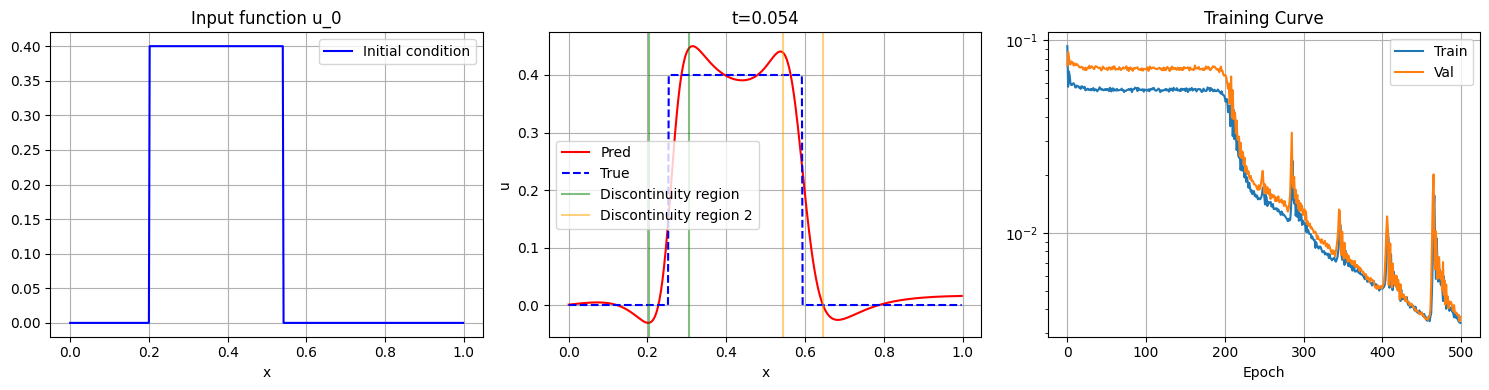

Total parameters: 787,417, trainable parameters: 787,417
L1 Loss (all points): 0.030, std: 0.008
L1 Loss (near discontinuity): 0.176, std: 0.059


In [28]:
checkpoint = torch.load("checkpoints/hyper_deeponet_checkpoint.pt", map_location=device, weights_only=False)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

input_data_test, output_data_test, discon_x_data_test = input_data[test_idx], output_data[test_idx], discon_x_data[test_idx]

l1_loss_all, l1_loss_near_discon_all = error_analysis_dataset_test(model, input_data_test, output_data_test, x, t_domain, discon_x_data_test, window_size=int(0.05 * Nx))
show_results(model, checkpoint, input_data_test, output_data_test, x, t_domain, discon_x_data_test, sample_id=1)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}, trainable parameters: {trainable_params:,}")
print(f"L1 Loss (all points): {np.mean(l1_loss_all):.3f}, std: {np.std(l1_loss_all):.3f}")
print(f"L1 Loss (near discontinuity): {np.mean(l1_loss_near_discon_all):.3f}, std: {np.std(l1_loss_near_discon_all):.3f}")